# Forecasting US Retail Sales of Sporting Goods, Hobby, Musical Instrument and Book Stores

**Time Series Analysis — project report**

Yassine Gharbi · EPF Montpellier, Data & AI (5A)

Data: U.S. Census Bureau, *Retail Sales: Sporting Goods, Hobby, Musical Instrument, and Book Stores* [MRTSSM451USN], retrieved from FRED, Federal Reserve Bank of St. Louis.

## 0. Introduction

### 0.1 Problem and business question

Stores selling sporting goods, hobby items, musical instruments and books run a seasonal business: December has been their best month in every year since 1992. The level of activity has also shifted several times over that period, most abruptly around 2020. A retailer or supplier who misjudges the December peak either runs out of stock at the busiest time of the year or is left with capital tied up in unsold inventory.

This report forecasts the **monthly sales of US sporting goods, hobby, musical instrument and book stores** and interprets every step of the analysis, both statistically and in business terms. The question it answers is:

> *How much will these stores sell in each of the coming months, and how much can a planner rely on that number?*

The forecast is meant to support four kinds of decisions:

- **Inventory and supply chain** — how much to order, and how early, ahead of the holiday peak.
- **Staffing** — how many seasonal employees to hire, and for which months.
- **Cash flow** — when revenue comes in relative to when suppliers must be paid.
- **Sector monitoring** — what lenders, commercial landlords and public authorities (sales-tax receipts) can expect from this retail segment.

### 0.2 Dataset

| | |
|---|---|
| **Series** | Retail Sales: Sporting Goods, Hobby, Musical Instrument, and Book Stores (United States) |
| **FRED identifier** | `MRTSSM451USN` |
| **Producer** | U.S. Census Bureau (release: *Monthly Retail Trade and Food Services*), retrieved from FRED (Federal Reserve Bank of St. Louis) |
| **Unit** | Millions of US dollars |
| **Seasonal adjustment** | **Not** seasonally adjusted |
| **Frequency** | Monthly |
| **Period covered** | January 1992 → July 2026 |
| **Observations** | 415, no missing values |

Source page: <https://fred.stlouisfed.org/series/MRTSSM451USN>

Three properties of the series shape the whole analysis:

1. **It is not seasonally adjusted.** The seasonal pattern is still in the data, which is exactly what a planner needs: the forecast must reproduce the December peak, not smooth it away.
2. **It is expressed in current dollars.** Growth in the series mixes volume growth and price increases, so periods of high inflation raise the level even if the quantities sold do not change.
3. **It aggregates four different kinds of stores.** Sporting goods, hobby, musical instrument and book stores are added together, so the series cannot tell which of them drives a given movement. It also measures a category of stores, not a product market: the same goods sold by other types of retailers are counted elsewhere.

### 0.3 Approach and plan

The analysis follows the **decomposition–reconstruction** logic of the course: a series is easier to understand and to forecast once it is split into a trend, a seasonal component and a residual. The components combine either by addition, $X_t = T_t + S_t + R_t$ (additive model), or by multiplication, $X_t = T_t \times S_t \times R_t$ (multiplicative model). Choosing between the two is the first modelling decision and is justified with the tools seen in class (band procedure, Buys-Ballot test, analysis of variance).

Three forecasting methods are then fitted and compared on the same held-out period:

1. **ETS / Holt-Winters** — exponential smoothing with trend and seasonal terms.
2. **SARIMA** — seasonal ARIMA, built from differencing and the ACF/PACF.
3. **Prophet** — additive regression model with trend changepoints and yearly seasonality.

All models are judged against two baselines (naive and seasonal naive) with MAE, MSE, RMSE and MAPE, on a chronological train/test split.

| Section | Content |
|---|---|
| 1 | Data loading and cleaning |
| 2 | Exploratory data analysis |
| 3 | Stationarity |
| 4 | ETS: decomposition and Holt-Winters |
| 5 | SARIMA |
| 6 | Prophet |
| 7 | Comparison of the forecasts |
| 8 | Conclusion |
| 9 | AI-usage policy |

Every output below is followed by a **technical reading** (what it means statistically) and a **business reading** (what it implies for a retailer, a distributor or a public authority).

### 0.4 Setup

Libraries, random seed, constants and plot style reused throughout the notebook. Model-specific imports are made in the section that uses them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

DATA_PATH = "MRTSSM451USN.csv"   # relative path; the raw file is never modified
SERIES_ID = "MRTSSM451USN"
SEASONAL_PERIOD = 12             # monthly data, yearly seasonality
UNIT = "millions of USD"

pd.set_option("display.width", 120)

In [2]:
# One palette and one set of chart defaults for the whole report
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE = PALETTE[:2]
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"   # text: primary, secondary, axis labels
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize": (12, 5), "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13,
    "lines.linewidth": 2, "legend.frameon": False,
})

## 1. Data loading and cleaning

This section turns the raw file into a clean monthly series and checks whether anything in it has to be repaired before the analysis: time index, frequency, missing values, then outliers.

### 1.1 Loading the raw file

In [3]:
raw = pd.read_csv(DATA_PATH)

print(f"{raw.shape[0]} rows x {raw.shape[1]} columns")
print(raw.dtypes.to_string())
raw.head()

415 rows x 2 columns
observation_date      str
MRTSSM451USN        int64


,observation_date,MRTSSM451USN
0,1992-01-01,2982
1,1992-02-01,2534
2,1992-03-01,2687
3,1992-04-01,2750
4,1992-05-01,2799


**Technical reading.** The file has 415 rows and 2 columns. `observation_date` is read as text, so it is not yet a time axis. `MRTSSM451USN` is read directly as integers, which already rules out two problems: a non-numeric entry would have turned the column into text, and a missing value would have turned it into decimals.

**Business reading.** Each row is the total sales of one month across all US stores of the category, in millions of dollars. The first row reads 2,982: about 3.0 billion dollars sold in January 1992.

### 1.2 Building the time index

In [4]:
sales = (
    raw.assign(date=pd.to_datetime(raw["observation_date"]))
       .set_index("date")[SERIES_ID]
       .rename("sales")
       .astype(float)
       .sort_index()
)

print(f"Index type  : {type(sales.index).__name__}")
print(f"First month : {sales.index.min():%Y-%m}")
print(f"Last month  : {sales.index.max():%Y-%m}")
print(f"Spacing     : {pd.infer_freq(sales.index)}")

Index type  : DatetimeIndex
First month : 1992-01
Last month  : 2026-07
Spacing     : MS


**Technical reading.** The dates are now a `DatetimeIndex` and pandas infers the spacing `MS` (month start): every timestamp is the first day of a month. The date is only a label for the whole month's total, not an observation made on that day. The values are converted to decimals because the models used later expect them.

**Business reading.** The history covers 34 complete years (1992 to 2025) plus the first seven months of 2026. Since 2026 has no December yet, it cannot be compared with the other years on annual totals, and the most recent holiday peak available to judge a forecast is December 2025.

### 1.3 Frequency and missing values

In [5]:
expected = pd.date_range(sales.index.min(), sales.index.max(), freq="MS")

integrity = pd.Series({
    "observations": len(sales),
    "months between first and last date": len(expected),
    "missing months": len(expected.difference(sales.index)),
    "duplicated dates": int(sales.index.duplicated().sum()),
    "missing values": int(sales.isna().sum()),
    "zero or negative values": int((sales <= 0).sum()),
}, name="count")

sales = sales.asfreq("MS")  # attach the monthly frequency to the index
print(f"Index frequency: {sales.index.freqstr}")
integrity.to_frame()

Index frequency: MS


,count
observations,415
months between first and last date,415
missing months,0
duplicated dates,0
missing values,0
zero or negative values,0


**Technical reading.** There are 415 observations for the 415 months between the first and the last date: no missing month, no duplicated date, no missing value. Nothing has to be imputed. The frequency `MS` is now attached to the index, which the forecasting models need in order to date their forecasts. All values are strictly positive, so a log transform and multiplicative models remain possible.

**Business reading.** Every month since January 1992 is reported, including each of the 34 Decembers. The forecasts therefore rest on the complete published history and on no value estimated by us.

### 1.4 Summary statistics

In [6]:
summary = sales.describe().round(0)
summary["cv (%)"] = round(sales.std() / sales.mean() * 100, 1)

print(f"Minimum reached in {sales.idxmin():%Y-%m} | maximum reached in {sales.idxmax():%Y-%m}")
summary.to_frame()

Minimum reached in 1992-02 | maximum reached in 2025-12


,sales
count,415.0
mean,6088.0
std,1883.0
min,2534.0
25%,4903.0
50%,5931.0
75%,7154.0
max,12293.0
cv (%),30.9


**Technical reading.** Monthly sales range from 2,534 (February 1992) to 12,293 (December 2025), a factor of 4.9. The mean (6,088) is above the median (5,931): the distribution is skewed to the right. The minimum is a February at the very start of the series and the maximum a December at the very end, which shows a trend and a seasonal pattern acting together. These global statistics mix the two, so they describe a distribution that is not stable over time; this is the question taken up in Section 3 (stationarity).

**Business reading.** The "average month" of about 6.1 billion dollars is not a usable planning figure: actual months go from 2.5 to 12.3 billion. A planner needs one number per month of the year and per year, which is what the models of Sections 4 to 6 produce.

### 1.5 Outliers

The usual rule flags any value further than 1.5 times the interquartile range (IQR) from the quartiles. It is applied first to the raw values.

In [7]:
q1, q3 = sales.quantile([0.25, 0.75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
iqr_flags = sales[(sales < lower) | (sales > upper)]

print(f"IQR bounds     : {lower:,.0f} to {upper:,.0f} {UNIT}")
print(f"Months flagged : {len(iqr_flags)}")
print(f"Calendar months: {sorted(iqr_flags.index.month.unique().tolist())}")
print(f"Years          : {iqr_flags.index.year.tolist()}")

IQR bounds     : 1,526 to 10,530 millions of USD
Months flagged : 13
Calendar months: [12]
Years          : [2005, 2006, 2007, 2012, 2013, 2014, 2015, 2016, 2021, 2022, 2023, 2024, 2025]


**Technical reading.** The rule flags 13 months and all of them are Decembers, in the years when the level was highest (2005 to 2007, 2012 to 2016, 2021 to 2025). These are seasonal peaks, not anomalies: the rule compares each month with the whole 34-year distribution and ignores both that December is always high and that the level has changed. It is not suited to a seasonal series with a trend.

**Business reading.** December is not an abnormal month to be removed; it is the month the forecast is most needed for. Cleaning the data with this rule would delete exactly what a retailer wants predicted.

**A screening adapted to the series.** Each month is instead compared with the same month one year earlier. The year-over-year change removes the seasonal pattern (same calendar month) and most of the trend. Unusual changes are flagged with the modified z-score of Iglewicz and Hoaglin (1993), built on the median and the median absolute deviation (MAD), with their recommended threshold of 3.5.

In [8]:
yoy = sales.pct_change(SEASONAL_PERIOD) * 100            # % change vs the same month, previous year

median = yoy.median()
mad = (yoy - median).abs().median()                       # median absolute deviation
robust_z = 0.6745 * (yoy - median) / mad                  # modified z-score
band = 3.5 * mad / 0.6745                                 # threshold expressed in points of change

outliers = pd.DataFrame({
    "sales": sales,
    "same month, previous year": sales.shift(SEASONAL_PERIOD),
    "yoy change (%)": yoy.round(1),
    "modified z-score": robust_z.round(2),
})[robust_z.abs() > 3.5]

print(f"Median change: {median:+.1f} % | MAD: {mad:.1f} points | flagging band: {median - band:+.1f} % to {median + band:+.1f} %")
print(f"Spread of the changes: standard deviation {yoy.std():.1f} points | robust equivalent (MAD / 0.6745) {mad / 0.6745:.1f} points")
print(f"Months flagged: {len(outliers)} of {yoy.notna().sum()} screened")
outliers

Median change: +2.7 % | MAD: 3.5 points | flagging band: -15.2 % to +20.6 %
Spread of the changes: standard deviation 10.1 points | robust equivalent (MAD / 0.6745) 5.1 points
Months flagged: 9 of 403 screened


,sales,"same month, previous year",yoy change (%),modified z-score
date,,,,
2018-12-01,8798.0,10428.0,-15.6,-3.58
2020-03-01,4955.0,5983.0,-17.2,-3.88
2020-04-01,3264.0,5887.0,-44.6,-9.22
2020-06-01,7822.0,6291.0,24.3,4.22
2020-09-01,7193.0,5950.0,20.9,3.55
2021-01-01,6858.0,5514.0,24.4,4.23
2021-03-01,8560.0,4955.0,72.8,13.67
2021-04-01,8035.0,3264.0,146.2,27.99
2021-05-01,7963.0,5931.0,34.3,6.16


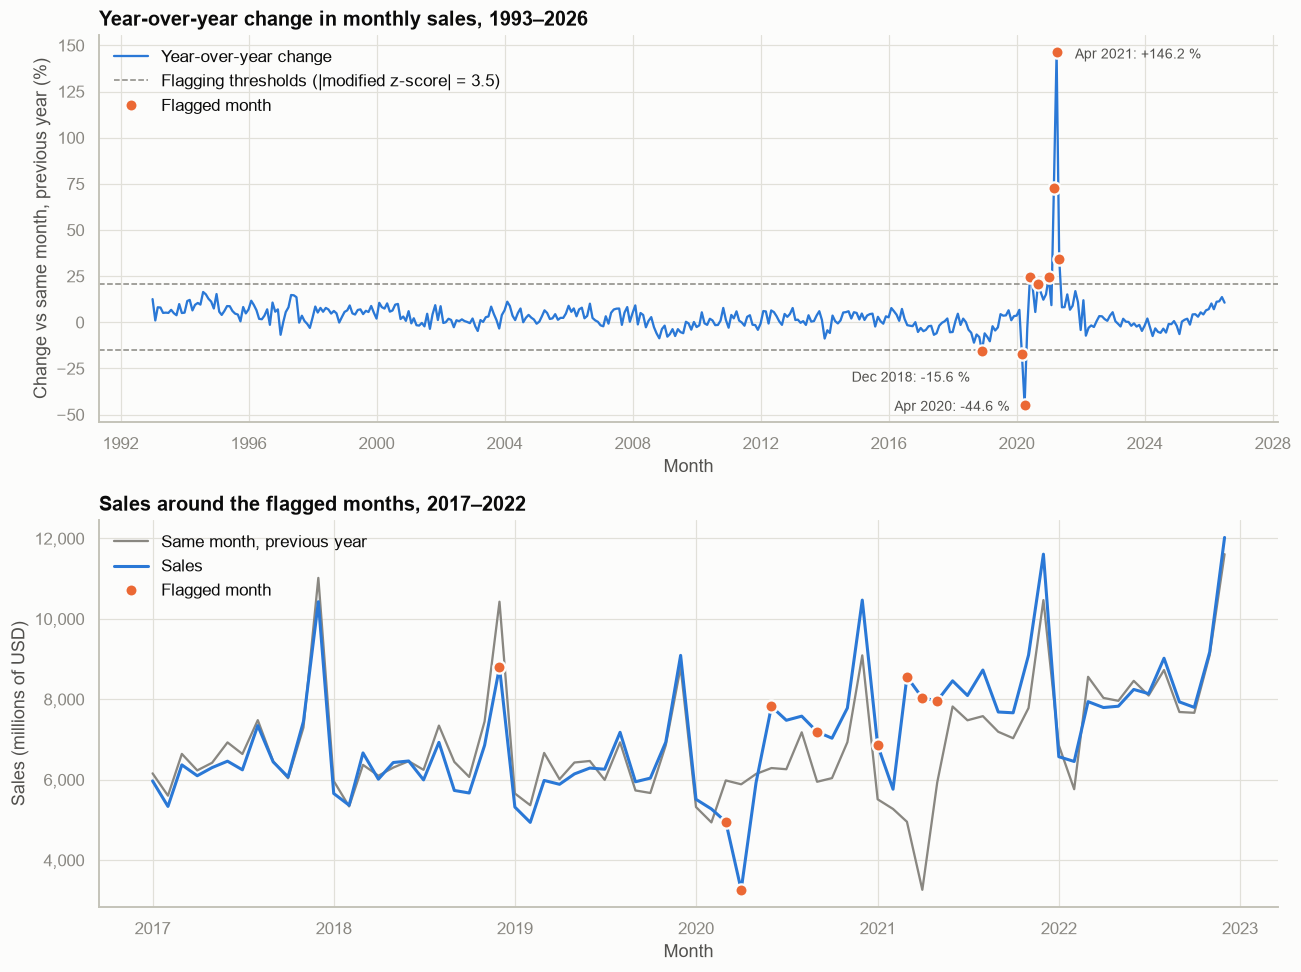

In [9]:
fig, (ax_change, ax_sales) = plt.subplots(2, 1, figsize=(12, 9))
dot = dict(marker="o", ls="", color=ORANGE, ms=8, mec=SURFACE, mew=1.5, label="Flagged month", zorder=3)

# Top panel: year-over-year change over the whole history
ax_change.plot(yoy, color=BLUE, lw=1.5, label="Year-over-year change")
ax_change.axhline(median + band, color=MUTED, lw=1, ls="--", label="Flagging thresholds (|modified z-score| = 3.5)")
ax_change.axhline(median - band, color=MUTED, lw=1, ls="--")
ax_change.plot(outliers["yoy change (%)"], **dot)
for month, offset in {"2018-12": (-8, -20), "2020-04": (-10, -4), "2021-04": (12, -4)}.items():
    value = outliers.loc[month, "yoy change (%)"].iloc[0]
    ax_change.annotate(f"{pd.Timestamp(month):%b %Y}: {value:+.1f} %", (pd.Timestamp(month), value),
                       xytext=offset, textcoords="offset points", fontsize=9, color=INK_2,
                       ha="right" if offset[0] < 0 else "left")
ax_change.set(title="Year-over-year change in monthly sales, 1993–2026",
              xlabel="Month", ylabel="Change vs same month, previous year (%)")
ax_change.legend(loc="upper left")

# Bottom panel: sales around the flagged months
window = slice("2017-01", "2022-12")
ax_sales.plot(sales.shift(SEASONAL_PERIOD)[window], color=MUTED, lw=1.5, label="Same month, previous year")
ax_sales.plot(sales[window], color=BLUE, label="Sales")
ax_sales.plot(outliers.loc[window, "sales"], **dot)
ax_sales.set(title="Sales around the flagged months, 2017–2022",
             xlabel="Month", ylabel=f"Sales ({UNIT})")
ax_sales.yaxis.set_major_formatter("{x:,.0f}")
ax_sales.legend(loc="upper left")

fig.tight_layout()
plt.show()

**Technical reading.**

- Sales typically grow by 2.7 % from one year to the next. A month is flagged when its change falls outside the band from −15.2 % to +20.6 %. The median and the MAD are used instead of the mean and the standard deviation because the latter are inflated by the very values being looked for: the standard deviation of the changes is 10.1 points, against a robust equivalent of 5.1.
- 9 months out of 403 are flagged (the first 12 months have no previous year to be compared with). Eight of them lie between March 2020 and May 2021; the ninth is December 2018.
- **April 2020** is the largest drop of the whole series: 3,264 against 5,887 a year earlier (−44.6 %, z-score −9.22), after a first fall in March 2020 (−17.2 %).
- **June 2020, September 2020 and January 2021** are flagged on the upside (+21 % to +24 %): sales rebound well above their level of the previous year.
- **March to May 2021** show the largest increases (+72.8 %, +146.2 %, +34.3 %). The March and April figures are partly a base effect, since they are compared with the two collapsed months of 2020. They are not only that: April 2021 (8,035) is still 36 % above April 2019 (5,887).
- The bottom panel shows the pattern behind these flags. Sales run above the previous-year line from June 2020 to the end of 2021, then only match it in 2022: the level stepped up and did not come back down. This is a shock followed by a level shift, not a set of isolated erroneous points.
- **December 2018** is an isolated case, just beyond the threshold: 8,798 against 10,428 in December 2017 (−15.6 %, z-score −3.58).

**Business reading.**

- April 2020 coincides with the first COVID-19 lockdowns in the United States. Stores sold about 2.6 billion dollars less than in April 2019, close to half a month of revenue. No model trained on past sales could have announced it. For cash-flow planning this is the argument for reading a forecast with its prediction interval and for keeping a reserve, rather than relying on the point forecast alone.
- From June 2020 the problem was reversed: in the flagged months, sales ran more than 20 % above the previous year, which for a retailer means a risk of stock-outs rather than of excess inventory. The causes of this rebound are examined in Section 6, where the changepoints are compared with documented events.
- December 2018 matters most for inventory planning: stock for the holiday peak is ordered months ahead, and that December came in 16 % below the previous one. The series itself does not say why. A sector-specific event is a possible explanation and has to be checked before it is cited.

**Decision: no value is modified.** The flagged months are real sales published by the Census Bureau, not recording errors. Replacing or smoothing them would make the history look calmer than it was and would lead to prediction intervals that are too narrow. The alternative, replacing the 2020 trough by an interpolated value, is therefore not applied. Two consequences follow for the rest of the report:

- The 2020–2021 shock is part of the data the models learn from. It will weigh on the residual diagnostics of ETS and SARIMA and on the changepoints detected by Prophet; the table `outliers` is kept to read those results.
- No flagged month falls in the last 24 months of the series, so the test period is free of them whether the horizon is 12 or 24 months.

The series `sales` (415 monthly observations, frequency `MS`, no missing value) is the object used in all the following sections.

## 2. Exploratory data analysis

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Time plot of the full series, with the **band procedure** (curves through yearly minima and maxima).
> - Seasonal plot (one line per year, by month) and boxplot by month.
> - Rolling mean and rolling standard deviation (12-month window).
> - **Buys-Ballot table** (years × months, with yearly and monthly means and standard deviations).
> - **Analysis of variance**: Fisher tests of the seasonal (column) effect and the trend (row) effect.
> - Chronological **train/test split**; from here on, everything is fitted on the training set only.

## 3. Stationarity

> **To do** — planned content, to be replaced by the cells of this section.
>
> - ADF and KPSS tests on the raw (or log) training series.
> - Regular differencing ($d$) and seasonal differencing ($D$, lag 12), re-tested after each step.
> - Conclusion on the orders of differencing carried into SARIMA.

## 4. ETS: decomposition and Holt-Winters

> **To do** — planned content, to be replaced by the cells of this section.
>
> - **Buys-Ballot test**: regression of the yearly standard deviation on the yearly mean, $\sigma_{p} = \alpha + \beta\,\bar{p} + \varepsilon$; significance of $\beta$ decides additive vs multiplicative.
> - Decomposition into trend, seasonal and residual components (period 12), additive vs multiplicative compared.
> - Seasonal coefficients and the conservation principle (sum to 0, or average to 1).
> - Holt-Winters / ETS fit: smoothing parameters, AIC/BIC, residual diagnostics.
> - Forecast over the test horizon with prediction intervals.

## 5. SARIMA

> **To do** — planned content, to be replaced by the cells of this section.
>
> - ACF and PACF of the differenced series.
> - Order selection $(p,d,q)(P,D,Q)_{12}$: candidates from the correlograms, compared by AIC/BIC.
> - Fit and coefficient significance.
> - Residual diagnostics: residual plot, ACF of residuals, Ljung-Box, histogram and QQ-plot.
> - Forecast over the test horizon with prediction intervals.

## 6. Prophet

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Fit with yearly seasonality (weekly and daily off); additive vs multiplicative `seasonality_mode`.
> - Trend and yearly components.
> - Detected changepoints compared with documented economic events.
> - Forecast over the test horizon with uncertainty intervals.

## 7. Comparison of the forecasts

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Baselines: naive and seasonal naive.
> - Metrics table (MAE, MSE, RMSE, MAPE) for the baselines and the three models on the same test set; what each metric penalises and which one matters most for the business case.
> - Overlaid plot of all forecasts against the actual values.
> - Discussion: accuracy, prediction intervals, interpretability, ease of maintenance.

## 8. Conclusion

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Key findings.
> - Limits of the analysis.
> - Business recommendations.
> - Possible improvements.

## 9. AI-usage policy

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Major prompts and how AI was used, built from `AI_USAGE_LOG.md`.